### <center>Demand Forecasting World of Comics</center>

Demand forecast for comic book toys

### Objective

Objetivo é construir um modelo preditivo para prever demanda de vendas de toys história em quadrinhos com séries temporais usando Inteligência Artificial.

### About Dataset

Este conjunto de dados contém uma base de dados de um cliente fictício sobre vendas de uma Loja de Brinquedos de Quadrinhos.

###  Data dictionary

O modelo deve receber como entrada os seguintes dados:

#### <center>Consumer data:</center>

| |Variável | Descrição|
|---|:-------------|:-----------|
| 1 |**ID:**|Identificador único de um consumidor|
| 2 |**City:**|Cidade/localidade onde um consumidor fez a compra|
| 3 |**State:**| Unidade Federativa onde um consumidor fez a compra)|
| 4 |**DateOfBirth:**|Data de nascimento de um consumidor|
| 5 |**Sex:**| Sexo de um consumidor |


#### <center>Store details:</center>

| |Variável | Descrição|
|---:|:-------------|:-----------|
| 1 |**ID:**|Identificador único de uma loja|
| 2 |**City:**|Cidade/localidade de uma loja compra|
| 3 |**State:**|  Unidade Federativa de uma loja |


#### <center>Product data:</center>


| |Variável | Descrição|
|---:|:-------------|:-----------|
| 1 |**ID:**|Identificador único de um produto|
| 2 |**Name:**|Nome de um produto|
| 3 |**Size:**|Tamanho de um produto (P,M,G ...)|


#### <center>Sales data:</center>

| |Variável | Descrição|
|---:|:-------------|:-----------|
| 1 |**ID:**|Identificador único de uma venda|
| 2 |**ProductID:**|Identificador único de um produto|
| 3 |**ClientID:**|Identificador único de um cliente|
| 4 |**Discount:**|Desconto aplicado em uma venda|
| 5 |**UnitPrice:**|Preço unitário de um produto vendido|
| 6 |**Quantity:**|Quantidade de produto vendido em uma venda|
| 7 |**StoreID:**|Identificador único de uma loja|
| 8 |**StoreID:**|Data de uma venda|

### Importing Necessary Modules and Functions

Este projeto usa várias bibliotecas. Isso pode ser bom ou ruim. Algumas dessas bibliotecas podem ser difíceis de instalar ou podem entrar em conflito com versões de outras bibliotecas.

Existem duas opções principais para instalar bibliotecas em Python. Uma delas é usa pip (um acrônimo para Pip Installs Python, ou Pip installs Python), uma ferramenta que vem com o Python e a outra opção é usar o Anaconda (https://anaconda.org).

Inicializaremos o projeto com todas as bibliotecas necessárias para atingir objetivos desejados.

---

This project requires Python 3.7 or higher:

In [455]:
# Importing libraries needed for Operating System Manipulation in Python
import os, sys
from platform import python_version

assert sys.version_info >= (3, 7)

And TensorFlow ≥ 2.8:

In [456]:
# Set environment variable to silence TF messages
%env TF_CPP_MIN_LOG_LEVEL=3

env: TF_CPP_MIN_LOG_LEVEL=3


In [457]:
from packaging import version
import tensorflow as tf

assert version.parse(tf.__version__) >= version.parse("2.8.0")

In [458]:
# Importing library for manipulation and exploration of datasets.
import numpy as np
import pandas as pd
import sidetable
from ydata_profiling import ProfileReport
from pandas.tseries.offsets import DateOffset


# Importing functions for dataset manipulation for time series
from time_series import ts

# Importing classes and libraries needed for the data pre-processing step.
from sklearn import preprocessing
from sklearn.preprocessing import (
    MinMaxScaler, StandardScaler,Normalizer,
    LabelEncoder, OneHotEncoder,
)

# Imports for time series analysis and modeling
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


# Importing libraries needed for predictive modeling, Machine Learning and Deep Learning algorithms..
from keras.preprocessing.sequence import TimeseriesGenerator
from keras.models import Sequential
from keras.layers import Dense, LSTM

# Importing classes, to calculate the evaluation metrics of the predictive models.
from sklearn.metrics import (
    mean_squared_error,mean_absolute_error
) 

# For Graph Rendering using matplotlib 
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib as m

# Formatting the graphics output
plt.style.use('fivethirtyeight')
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)
m.rcParams['axes.labelsize'] = 14
m.rcParams['xtick.labelsize'] = 12
m.rcParams['ytick.labelsize'] = 12
m.rcParams['text.color'] = 'k'

# Configuring how many rows and columns will be shown in the notebook
from IPython.display import display, Image
#pd.options.display.max_rows =None
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# To hide Future Warnings
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning) 
warnings.simplefilter(action = 'ignore', category = FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

### System and Libraries Report

A função a seguir confirmar as informações de hardware, sistema e versões da bibliotecas usadas neste projeto

In [459]:
# This module is used to record versions of other modules used in this jupyter.
print("=" *40)
%reload_ext watermark
%watermark -a "Helber" --iversions
# Python Language Version
print('Python Language Version Used In This Jupyter Notebook:', python_version())
functions_aux.info_system()

Author: Helber

sidetable  : 0.9.1
packaging  : 21.3
sklearn    : 0.0.post1
joypy      : 0.2.6
statsmodels: 0.14.0
plotly     : 5.6.0
researchpy : 0.3.2
sys        : 3.9.7 (default, Sep 16 2021, 13:09:58) 
[GCC 7.5.0]
numpy      : 1.21.6
tensorflow : 2.11.0
matplotlib : 3.6.3
pandas     : 1.5.3
seaborn    : 0.11.2

Python Language Version Used In This Jupyter Notebook: 3.9.7
======================================== System Information ========================================
System: Linux
Release: 5.15.0-71-generic
Version: #78~20.04.1-Ubuntu SMP Wed Apr 19 11:26:48 UTC 2023
Machine: x86_64
======================================== CPU Info ========================================
Physical cores: 6
Total cores: 12
Max Frequency: 4800.00Mhz
Min Frequency: 800.00Mhz
======================================== Memory Information ========================================
Total: 31.19GB


---

### 1. The end-to-end pipeline of an Machine Learning project

### 1.1. An overview of the end-to-end pipeline

Um pipeline de ML é uma sequência de etapas para conduzir um projeto de ML. Essas etapas seguem:

- **Definicão do problema e coleta de dados:** Define objetivo do problema em termo de negócios como um problema de ML e colete os dados de que você precisa.

- **Pré-processamento de dados e engenharia de recursos:** Processar os dados em um formato adequado que
pode ser inserido nos algoritmos de ML.Assim como,selecionar ou gerar recursos relacionados
para a saída de destino para melhorar o desempenho dos algoritmos.Além disso, essa etapa geralmente é realizada explorando primeiro o conjunto de dados para ter uma noção de suas características. As operações devem acomodar os algoritmos de ML específicos que você está considerando.

- **Seleção de algoritmo de ML:** Selecione algoritmos de ML apropriados para a tarefa que você
gostaria de testar, com base em seu conhecimento prévio do problema e em sua
experiência.

- **Treinamento e avaliação do modelo:** Aplique o algoritmo (ou algoritmos) de ML selecionado
para treinar um modelo de ML com seus dados de treinamento e avaliar seu desempenho em
o conjunto de dados de validação.

- **Ajuste de hiperparâmetros:** Tente alcançar um melhor desempenho iterativamente
ajustando os hiperparâmetros do modelo.

- **Implantação de serviços e monitoramento de modelos:** Implante a solução final de ML e monitore seu desempenho para que você possa manter e melhorar o pipeline continuamente.

Dessa forma, como resultado você pode ver, um projeto de ML é um processo humano em loop. Bem como, iniciando com definnição do problema e coleta de dados, assim o pipeline envolve várias etapas de processamento de dados, que normalmente acontecem de forma assíncrona conforme a figura a seguir. 

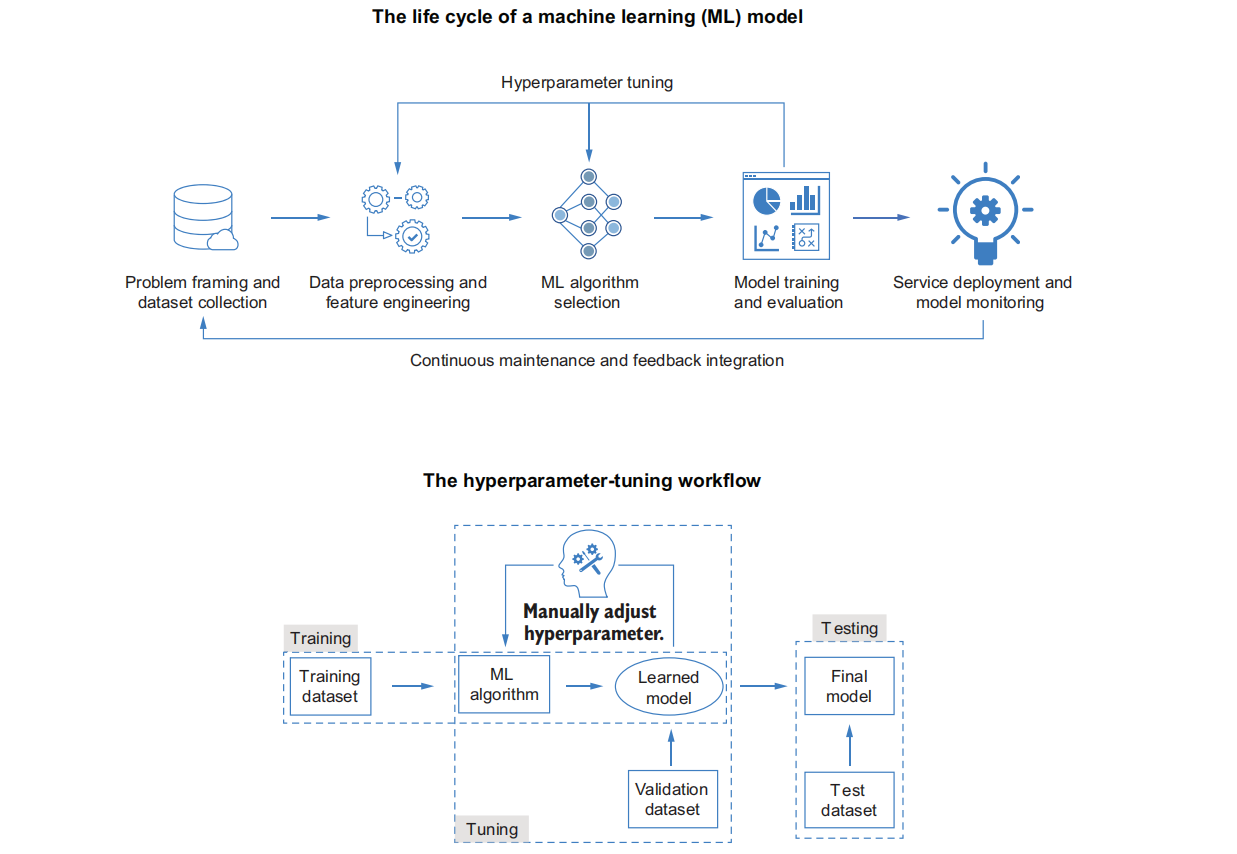

> Source: (QINGQUAN.S; HAIFENG.J; X.HU, 2022) 

A primeira coisa que você precisa fazer em qualquer projeto de ML é define o problema e coletar os dados correspondentes.Assim, a definição do problema exige que você especifique as entradas e saídas do modelo de ML. No problema de vendas de video games, as entradas são conjunto de características que descrevem os jogos. Recomendo o livro Automated Machine Learning in Action para saber mais sobre todos esses fluxos de pipelines.

### 2. Exploratory data analysis & Data preprocessing

Em primeira análise, o próximo passo é fazer algum pré-processamento para transformar os dados em um formato adequado para alimentar os algoritmos de ML. O procedimento geralmente envolve a etapa de análise exploratória de dados (EDA) com base em suposições anteriores ou perguntas sobre os dados.Dessa forma, a EDA pode nos ajude a nos familiarizar com o dataset e obter mais informações sobre ele, para permitir uma melhor preparação de dados. Assim como, algumas perguntas frenquente incluem as seguintes:

- Quais são os tipos de dados dos valores em cada recurso? São strings ou outras
objetos que podem ser usados em etapas posteriores no pipeline ou precisam ser Transformado?

- Quantos valores distintos cada variável possui? São valores numéricos, valores categóricos, ou outra coisa?

- Quais são as escalas e estatísticas básicas de cada variável? Podemos ganhar algum
insights visualizando a distribuição dos valores ou correlações entre eles?

- Há valores ausentes nos dados? Em caso afirmativo, temos que removê-los ou preencher
com alguma abordagem de imputação?

Diante disso, na prática dados de diferentes formatos geralmente requerem técnicas de pré-processamento de dados personalizados conforme o seu formato e características, de acordo com os problemas que nos interessam que estamos trabalhando  para modelos de ML e assim por diante. Este é geralmente um processo empírico heurístico, resultando na proposta de várias operações ad hoc. Na seção a seguir mostra o processo da análise exploratória e pré-processamento de dados.Mas antes disso, precisamos carregar o conjunto de dados ou dataset.

### 2.1. Load Data

In [460]:
# Loading the data train with pandas

%time
df     = pd.read_excel('dataset/df.xlsx',skiprows = range(0, 4))
client = pd.read_csv('dataset/client.csv')
prod   = pd.read_csv('dataset/prod.csv')
store  = pd.read_csv('dataset/store.csv')
sales  = pd.read_csv('dataset/sales.csv')

CPU times: user 3 µs, sys: 1e+03 ns, total: 4 µs
Wall time: 6.44 µs


In [461]:
# drop columns index
df.drop(df.columns[[0,1]], axis=1, inplace=True)

### 2.1. Data set overview

Iniciaremos o desenvolvimento com uma visualização mais sofisticada para obter uma visão completa dataset, é por meio da biblioteca **pandas-profiling** inclui um relatório de perfil. **Dessa forma, esse relatório sintetizará os tipos das colunas e permitirá que você visualize os detalhes das estatísticas dos quantis, as estatísticas descritivas, histogramax, os valores comuns e os valores extremos (outliers).**

Portanto, com base nas quatro perguntas mencionadas na seção anterior, realizaremos um pré-processamento preliminar nos dados dessas perguntas, assim:

- Qual são os tipos de dados em cada recurso?

- Quantos valores distintos cada recurso tem no dataset?

- Quais são a escala e as estatísticas básicas de cada recurso?

- Há valores ausentes e duplicados contidos nos dados?

Este relatório mostrará muitas informações importantes no conjunto de dados e, à medida que desenvolveremos o projeto, seguiremos grande parte do relatório como um guia para cada etapa do projeto, sempre referindo-se o possível à sua seção de análise. Portanto, o código a seguir mostra os estágios iniciais do projeto.

In [462]:
# view the first five rows of the dataframe
df.head()

,ID,ProductID,ClientID,Discount,UnitPrice,Quantity,StoreID,Date
0,80260d682079b6090c8285b398c50d97,002552c0663708129c0019cc97552d7d3,14001,0.08,249.2,1,4,2018-12-10
1,3275736da1234f55d52bdf09d86b93bc,001b237c0e9bb435f2e54071129237e93,14001,0.10,162.4,1,4,2019-04-25
2,f3513eec8f1434b5b7e04ddf3598df40,00066f42aeeb9f3007548bb9d3f33c381,14001,0.10,194.6,1,4,2019-07-17
3,7180475b60fe6bbbde424d39704a1177,001b72dfd63e9833e8c02742adf472e33,14002,0.10,201.6,2,1,2018-04-10
4,76600853a200fe87e141adae6b35674c,00210e41887c2a8ef9f791ebc780cc363,14002,0.10,406.0,1,1,2019-01-21


In [463]:
# convert column names to lowercase
df.columns = df.columns.str.lower()

In [464]:
# Create a profile report
df_report = ProfileReport(df, title="Comic Toy Story, world of comics report")

# Function object call
df_report.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

### Feature engineering

In [465]:
df['sales_amount'] = df.unitprice * df.quantity
df['sales_discount'] = df.sales_amount * df.discount
df['final_sales_price'] = df.sales_amount - df.sales_discount
# Sort
df=df.sort_values('date')

In [466]:
# Converte a coluna de data em índice
df.index = pd.to_datetime(df['date'], format = '%Y-%m-%d %H:%M:%S')

In [467]:
# Série temporal da demanda média de vendas de briquedos por semana
ts_per_week = df.iloc[:,[10]].resample('W').mean()
ts_per_week = ts_per_week.dropna()
ts_per_week.head()

,final_sales_price
date,
2018-03-04,196.276957
2018-03-11,195.496744
2018-03-18,191.295728
2018-03-25,184.333333
2018-04-01,189.952105


### Decomposição da Série Temporal

In [468]:
# Additive Decomposition
addi_decomposition = sm.tsa.seasonal_decompose(ts_per_week, model = 'aditive',extrapolate_trend='freq' ,period=7)

# Multiplicative Decomposition 
mult_decomposition  = sm.tsa.seasonal_decompose(ts_per_week, model = 'multiplicative',extrapolate_trend = 'freq', period=7)

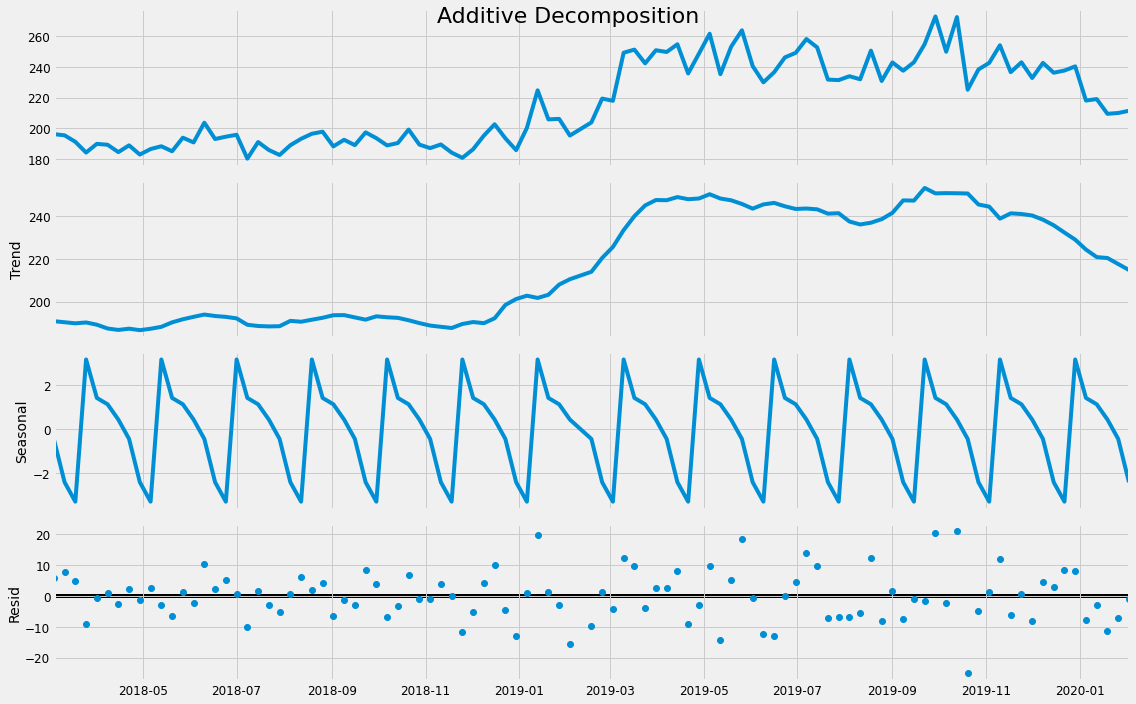

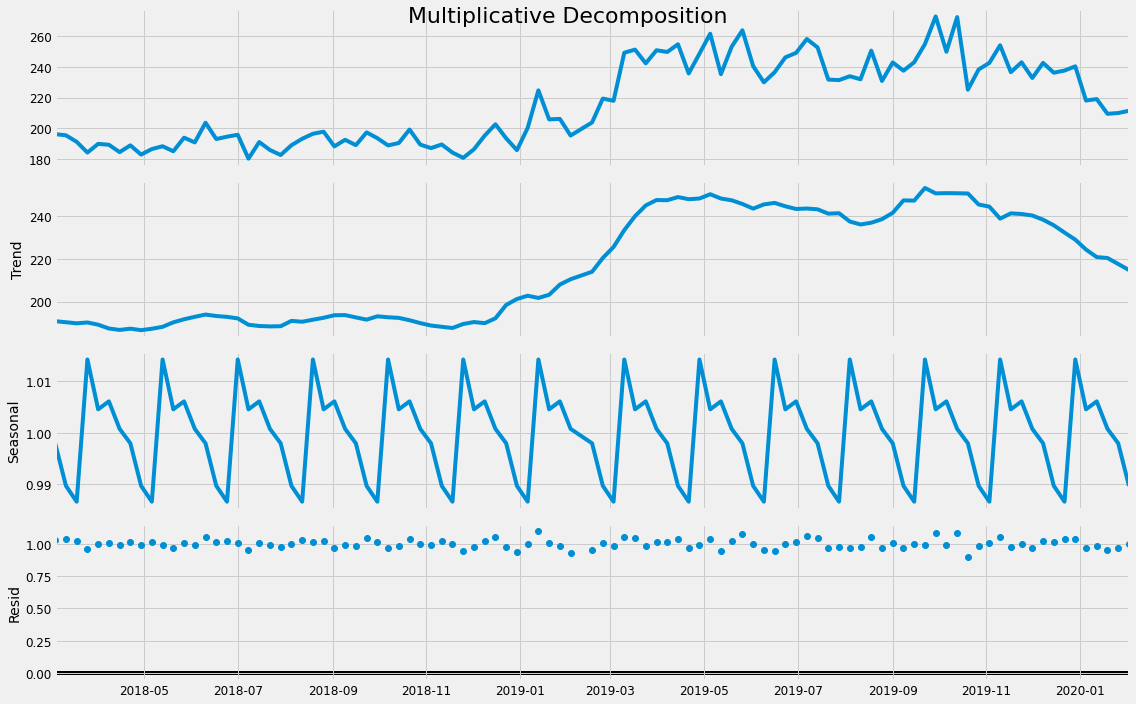

In [469]:
# Plot
plt.rcParams.update({'figure.figsize': (16,10)})
addi_decomposition.plot().suptitle('Additive Decomposition', fontsize = 22)
mult_decomposition.plot().suptitle('Multiplicative Decomposition', fontsize = 22)
plt.show()

### Teste de Estacionariedade

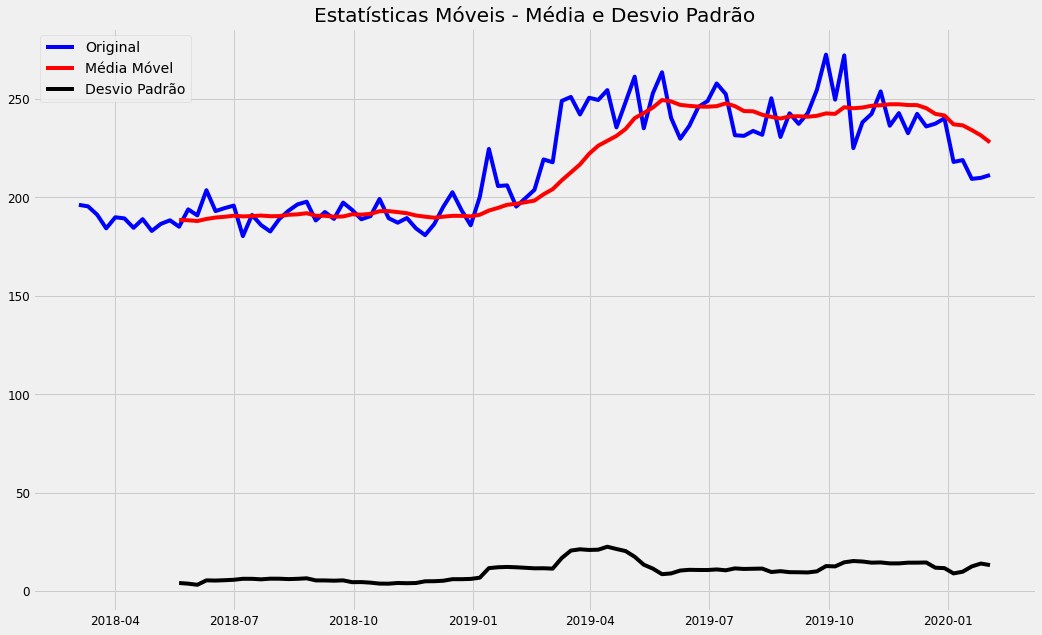


Resultado do Teste Dickey-Fuller:

Estatística do Teste            -1.610632
Valor-p                          0.477644
Número de Lags Consideradas      1.000000
Número de Observações Usadas    98.000000
Valor Crítico (1%)              -3.498910
Valor Crítico (5%)              -2.891516
Valor Crítico (10%)             -2.582760
dtype: float64

Conclusão:

O valor-p é maior que 0.05 e, portanto, não temos evidências para rejeitar a hipótese nula.
Essa série provavelmente não é estacionária.


In [470]:
# Vamos testar a estacionaridade da série antes de qualquer transformação
ts.test_stationarity(ts_per_week)

### Diferenciação 

Vamos primeiro colocar os dados na mesma escala e, em seguida aplicar a diferenciação.

In [471]:
# Cria uma instância do padronizador
scaler = MinMaxScaler()

In [472]:
# Fit in time serie
ts_scaler=scaler.fit_transform(ts_per_week)

# Transform in log
#ts_per_week_log = np.log(ts_per_week)

In [473]:
# Cria um dataframe
ts_scaler = pd.DataFrame(ts_scaler,index=ts_per_week.index,columns=["final_sales_price"])
ts_scaler.head()

,final_sales_price
date,
2018-03-04,0.172387
2018-03-11,0.163922
2018-03-18,0.118340
2018-03-25,0.042796
2018-04-01,0.103761


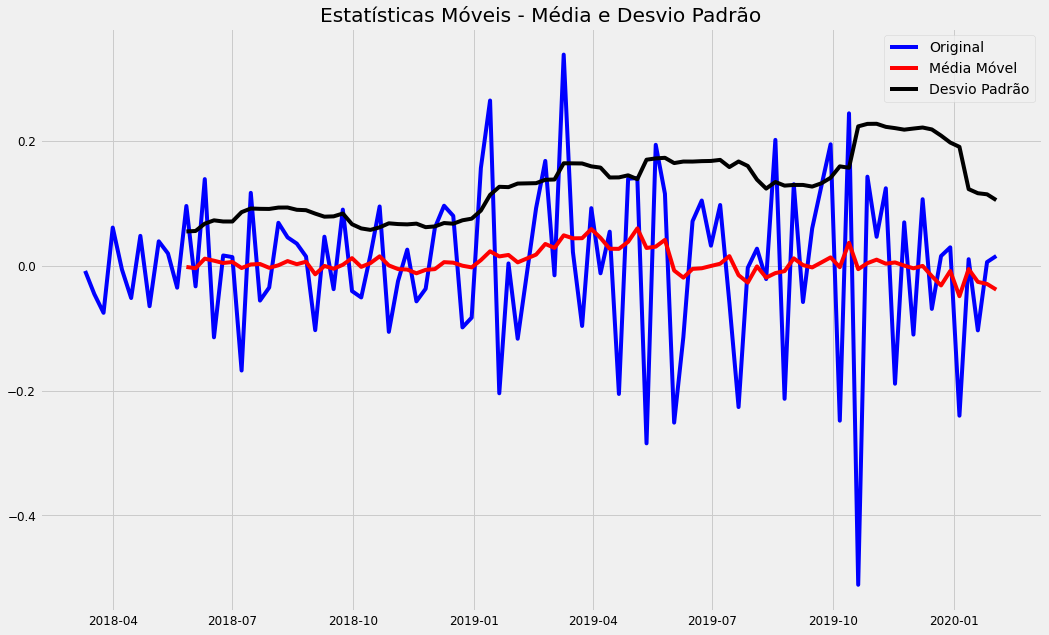


Resultado do Teste Dickey-Fuller:

Estatística do Teste           -1.450471e+01
Valor-p                         5.854735e-27
Número de Lags Consideradas     0.000000e+00
Número de Observações Usadas    9.800000e+01
Valor Crítico (1%)             -3.498910e+00
Valor Crítico (5%)             -2.891516e+00
Valor Crítico (10%)            -2.582760e+00
dtype: float64

Conclusão:

O valor-p é menor que 0.05 e, portanto, temos evidências para rejeitar a hipótese nula.
Essa série provavelmente é estacionária.


In [474]:
# Aplica a diferenciação
first_diff=ts_scaler.final_sales_price - ts_scaler.final_sales_price.shift(1)

# Remove valores NA gerados no processo
first_diff = first_diff.dropna()

# Testa a estacionaridade
ts.test_stationarity(first_diff)

### Split Train/Test

In [475]:
# Convert um array e depois aplica reshape
ts_sample = first_diff.to_numpy().reshape(-1,1)

In [476]:
# Inverte a padronização
ts_true = scaler.inverse_transform(ts_sample)

In [477]:
# Cria dataframe para preparação dos dados
df_pred = pd.DataFrame(ts_true, index=first_diff.index,columns=["Average_sales_per_week"])

In [478]:
df_pred.head()

,Average_sales_per_week
date,
2018-03-11,179.608833
2018-03-18,176.188029
2018-03-25,173.426651
2018-04-01,186.007817
2018-04-08,179.821705


In [479]:
# Prepare training and testing datasets
train = df_pred.iloc[:78]
test = df_pred.iloc[78:]

In [480]:
# Cria o padronizador
scaler2 = MinMaxScaler()

# Fit com dados de treino
scaler2.fit(train)

# Transform em treino e teste
scaled_train = scaler.transform(train)
scaled_test = scaler.transform(test)

In [481]:
scaled_train[:5]

array([[-0.00846548],
       [-0.04558195],
       [-0.07554351],
       [ 0.06096491],
       [-0.00615577]])

In [482]:
scaled_test[:5]

array([[ 0.05970653],
       [ 0.12756701],
       [ 0.19432907],
       [-0.24824989],
       [ 0.24392306]])

### Pré-Processamento da Série Temporal with TimeseriesGenerator

O TimeseriesGenerator do Keras é uma classe que permite gerar sequências de dados de séries temporais para uso em modelos de redes neurais. Ele é útil para problemas de aprendizado de máquina envolvendo previsão de séries temporais, como previsão de valores futuros de ações, previsão de demanda de energia, previsão de preços de commodities, entre outros.

O TimeseriesGenerator divide uma série temporal em sequências menores, criando uma janela deslizante de observações. Isso significa que, para cada sequência, ele seleciona um intervalo de observações e as usa como entrada para o modelo de rede neural, com o objetivo de prever o próximo valor da série temporal.

O TimeseriesGenerator oferece várias opções de configuração, como o comprimento das sequências, o espaçamento entre elas, o número de recursos, a função de normalização e a possibilidade de embaralhar as sequências antes do treinamento.

Ele é útil porque simplifica o processo de pré-processamento e preparação de dados, tornando-o mais fácil e rápido. Além disso, o TimeseriesGenerator é compatível com uma variedade de modelos de redes neurais, permitindo que os usuários experimentem diferentes arquiteturas de modelos para encontrar a que melhor se adapta ao problema em questão.

In [483]:
# Janela de previsão que o modelo será treinado
n_input = 7

In [484]:
# Cria o generator
generator = TimeseriesGenerator(scaled_train, scaled_train, length = n_input, batch_size = 1)

In [485]:
# Extrai o primeiro item do generator para visualizar
X,y = generator[0]

In [486]:
X.shape

(1, 7, 1)

In [487]:
y.shape

(1, 1)

In [488]:
print(f'\nArray de Entrada (x): \n{X.flatten()}') # unidimensional
print(f'\nPrevisão (y): \n {y}')


Array de Entrada (x): 
[-0.00846548 -0.04558195 -0.07554351  0.06096491 -0.00615577 -0.0518704
  0.04769561]

Previsão (y): 
 [[-0.0649168]]


Nessa caso, estamos ensinado ao modelo um padrão de uma janela de 7 dias para previsão da média de vendas.

## Modelagem

A arquitetura LSTM (Long Short-Term Memory) é um tipo de rede neural recorrente (RNN) que foi projetada para resolver o problema do gradiente desvanecente (vanishing gradient) em redes neurais tradicionais. As LSTMs foram introduzidas por Hochreiter e Schmidhuber em 1997, e se tornaram amplamente utilizadas em tarefas de processamento de linguagem natural, reconhecimento de fala, previsão de séries temporais, entre outros.

As LSTMs são compostas por unidades de memória, chamadas células LSTM, que possuem um estado de memória interno que é atualizado e modulado por três portões: o portão de entrada (input gate), o portão de esquecimento (forget gate) e o portão de saída (output gate). Esses portões permitem que as LSTMs aprendam e retenham informações relevantes por períodos prolongados de tempo e esqueçam informações irrelevantes.

O portão de entrada controla a atualização do estado da célula com base nas novas entradas. O portão de esquecimento decide quais informações da célula antiga devem ser mantidas ou esquecidas. E o portão de saída controla a saída da célula, modulando o estado atual da célula. Todos esses portões são controlados por funções de ativação, que determinam a quantidade de informação que deve ser mantida, esquecida ou atualizada.

A arquitetura LSTM pode ser usada para previsão de séries temporais, classificação de texto, tradução automática, reconhecimento de fala, entre outras tarefas de aprendizado de máquina. Devido à sua habilidade em lidar com dependências de longo prazo, as LSTMs são particularmente úteis em tarefas que exigem a compreensão de sequências complexas de dados.


In [489]:
# Número de atributos
n_features = 1 # é porque nossa série é univariada, só temos uma coluna d total de vendas

A definição do número de neurônios em um modelo LSTM criado com o Keras depende do problema que você está tentando resolver e da quantidade de dados que você tem disponível para treinar o modelo. Em geral, um número maior de neurônios pode levar a um modelo mais complexo e capaz de aprender relações mais complexas nos dados, mas pode levar a problemas de overfitting se a quantidade de dados disponíveis for insuficiente para treinar o modelo adequadamente.

Aqui estão algumas diretrizes gerais para ajudá-lo a escolher o número de neurônios em um modelo LSTM:

- Comece com uma quantidade menor de neurônios e vá aumentando gradualmente até que o modelo atinja um bom desempenho nos dados de treinamento e de teste. Observe que o aumento do número de neurônios também aumentará o tempo de treinamento do modelo.


- Use métodos de regularização, como dropout ou L2, para ajudar a prevenir o overfitting do modelo.


- Considere o número de timesteps e de variáveis de entrada no seu conjunto de dados. Em geral, um número maior de timesteps e de variáveis pode exigir um número maior de neurônios para que o modelo seja capaz de capturar relações complexas nos dados.


- Experimente diferentes números de neurônios e observe o desempenho do modelo em um conjunto de validação. Escolha o número de neurônios que resulta no melhor desempenho no conjunto de validação.

In [490]:
# Cria o modelo
model_lstm = tf.keras.Sequential()
model_lstm.add(tf.keras.layers.LSTM(units = 100, input_shape = (n_input, n_features)))
model_lstm.add(tf.keras.layers.Dropout(rate = 0.2)) # regularização
model_lstm.add(tf.keras.layers.Dense(units = 1))

In [491]:
# Compila o modelo
model_lstm.compile(loss = 'mse', optimizer = 'adam')

In [492]:
# Sumário
model_lstm.summary()

Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_7 (LSTM)               (None, 100)               40800     
                                                                 
 dropout_7 (Dropout)         (None, 100)               0         
                                                                 
 dense_7 (Dense)             (None, 1)                 101       
                                                                 
Total params: 40,901
Trainable params: 40,901
Non-trainable params: 0
_________________________________________________________________


In [493]:
# Treinamento
model_lstm.fit(generator, epochs = 280)

Epoch 1/280
71/71 [==============================] - 2s 3ms/step - loss: 0.0146
Epoch 2/280
71/71 [==============================] - 0s 3ms/step - loss: 0.0134
Epoch 3/280
71/71 [==============================] - 0s 2ms/step - loss: 0.0134
Epoch 4/280
71/71 [==============================] - 0s 3ms/step - loss: 0.0140
Epoch 5/280
71/71 [==============================] - 0s 3ms/step - loss: 0.0130
Epoch 6/280
71/71 [==============================] - 0s 2ms/step - loss: 0.0125
Epoch 7/280
71/71 [==============================] - 0s 3ms/step - loss: 0.0129
Epoch 8/280
71/71 [==============================] - 0s 4ms/step - loss: 0.0126
Epoch 9/280
71/71 [==============================] - 0s 3ms/step - loss: 0.0134
Epoch 10/280
71/71 [==============================] - 0s 2ms/step - loss: 0.0136
Epoch 11/280
71/71 [==============================] - 0s 2ms/step - loss: 0.0122
Epoch 12/280
71/71 [==============================] - 0s 3ms/step - loss: 0.0128
Epoch 13/280
71/71 [=================

In [494]:
# Erro por epoch
loss_per_epoch = model_lstm.history.history['loss']

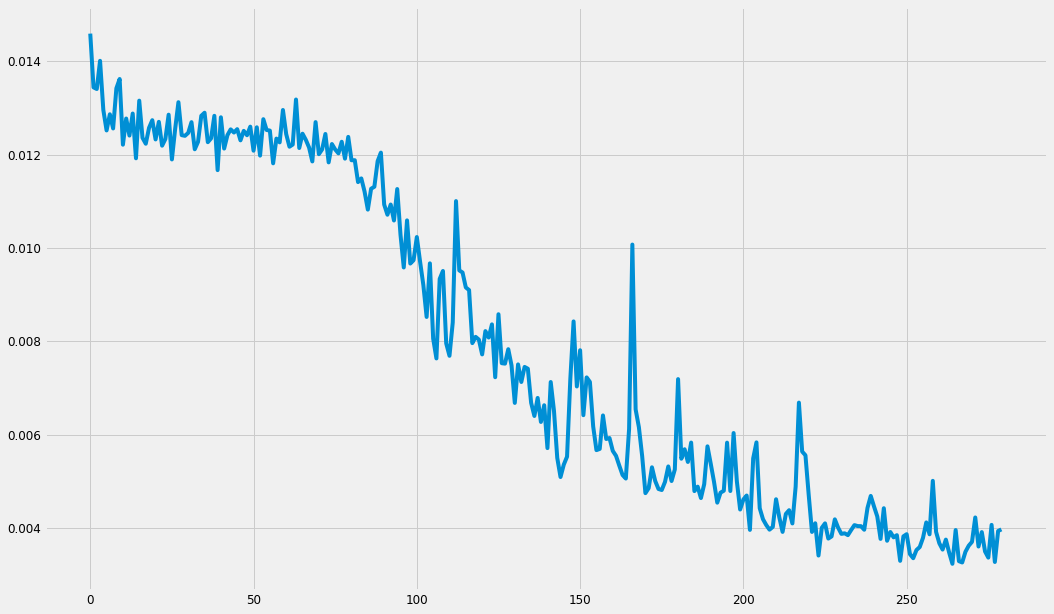

In [495]:
plt.plot(range(len(loss_per_epoch)), loss_per_epoch)

In [496]:
# Último batch de treino
last_batch_train = scaled_train[-n_input:]

In [497]:
# Ajusta o shape
last_batch_train= last_batch_train.reshape((1, n_input, n_features))

In [498]:
# Previsão em treino
model_lstm.predict(last_batch_train)

1/1 [==============================] - 0s 239ms/step


array([[-0.13910727]], dtype=float32)

### Model Testing and Evaluation Predictions

In [499]:
# Cria um lista vazia para previsões
y_pred = []

In [500]:
# Primeiro batch
first_eval_batch = scaled_test[-n_input:]

In [501]:
# Batch corrente
current_batch = first_eval_batch.reshape((1, n_input, n_features))

In [502]:
current_batch

array([[[ 0.01536244],
        [ 0.02933537],
        [-0.24028401],
        [ 0.01031351],
        [-0.10364646],
        [ 0.00574992],
        [ 0.01547261]]])

In [503]:
# Loop de previsão
for i in range(len(test)):
    
    # Obtém o valor de previsão para o primeiro lote
    current_pred = model_lstm.predict(current_batch)[0]
    
    # Adiciona a previsão na matriz
    y_pred.append(current_pred) 
    
    # Usa a previsão para atualizar o lote e remover o primeiro valor
    current_batch = np.append(current_batch[:,1:,:], [[current_pred]], axis = 1)

1/1 [==============================] - 0s 12ms/step


In [504]:
y_pred

[array([-0.0865351], dtype=float32),
 array([0.17747225], dtype=float32),
 array([0.05838843], dtype=float32),
 array([-0.0934634], dtype=float32),
 array([-0.05769311], dtype=float32),
 array([0.00804453], dtype=float32),
 array([0.10731906], dtype=float32),
 array([-0.04804333], dtype=float32),
 array([0.14329381], dtype=float32),
 array([-0.06826531], dtype=float32),
 array([-0.02404653], dtype=float32),
 array([0.01619137], dtype=float32),
 array([-0.0009067], dtype=float32),
 array([-0.01358806], dtype=float32),
 array([-0.01401909], dtype=float32),
 array([0.01426201], dtype=float32),
 array([0.02340887], dtype=float32),
 array([-0.02594359], dtype=float32),
 array([-0.00289339], dtype=float32),
 array([-0.00132862], dtype=float32),
 array([0.00125994], dtype=float32)]

In [505]:
# Inverte a padronização
true_y_pred = scaler2.inverse_transform(y_pred)

In [506]:
# Adiciona as previsões no dataframe de dados de teste
test["Predictions"] = true_y_pred
test

,Average_sales_per_week,Predictions
date,,
2019-09-15,185.891840,149.198887
2019-09-22,192.146136,164.345491
2019-09-29,198.299196,157.513425
2019-10-06,157.509335,148.801397
2019-10-13,202.869978,150.853607
2019-10-20,133.288080,154.625100
2019-10-27,193.519593,160.320669
2019-11-03,184.649325,151.407233
2019-11-10,191.808635,162.384609


### Evaluation

In [507]:
# Calcula o erro
MAE_lstm = mean_absolute_error(test['Average_sales_per_week'], test['Predictions'])
print('MAE:', MAE_lstm)

MSE_lstm = mean_squared_error(test['Average_sales_per_week'], test['Predictions'])
print('MSE:', MSE_lstm)

RMSE_lstm = mean_squared_error(test['Average_sales_per_week'], test['Predictions'], squared = False)
print('RMSE:', RMSE_lstm)


MAE: 26.711803932520215
MSE: 836.1071461310142
RMSE: 28.91551739345181


### Previsão de Demanda de vendas para os próximos 21 dias

Vamos fazer o Forecasting para os próximos 21 dias de horizonte de previsão. A função DateOffset() vai nos ajudar a criar as datas.

In [508]:
# Last date the time series
test.index[-1]

Timestamp('2020-02-02 00:00:00')

In [509]:
# Cria sequência de datas a partir da última data da nossa série original
dates_to_predict_forecasting = [test.index[-1] + DateOffset(days = x) for x in range(0, 22)]

In [510]:
# Visualiza as datas criadas
dates_to_predict_forecasting 

[Timestamp('2020-02-02 00:00:00'),
 Timestamp('2020-02-03 00:00:00'),
 Timestamp('2020-02-04 00:00:00'),
 Timestamp('2020-02-05 00:00:00'),
 Timestamp('2020-02-06 00:00:00'),
 Timestamp('2020-02-07 00:00:00'),
 Timestamp('2020-02-08 00:00:00'),
 Timestamp('2020-02-09 00:00:00'),
 Timestamp('2020-02-10 00:00:00'),
 Timestamp('2020-02-11 00:00:00'),
 Timestamp('2020-02-12 00:00:00'),
 Timestamp('2020-02-13 00:00:00'),
 Timestamp('2020-02-14 00:00:00'),
 Timestamp('2020-02-15 00:00:00'),
 Timestamp('2020-02-16 00:00:00'),
 Timestamp('2020-02-17 00:00:00'),
 Timestamp('2020-02-18 00:00:00'),
 Timestamp('2020-02-19 00:00:00'),
 Timestamp('2020-02-20 00:00:00'),
 Timestamp('2020-02-21 00:00:00'),
 Timestamp('2020-02-22 00:00:00'),
 Timestamp('2020-02-23 00:00:00')]

In [511]:
# Vamos agora criar um novo dataframe 
# O índice (data) será a sequência de datas futuras
# O nome da coluna de dados extraímos da série original
# ATENÇÃO: Não estamos extraindo os dados da série original, somente o nome da coluna
dates_future = pd.DataFrame(index = dates_to_predict_forecasting[1:], columns = ["Average_sales_per_week"])

In [512]:
# Visualiza os dados
# Entendeu por que os valores NaN? São datas futuras, e precisamos agora incluir nossas previsões.
dates_future

,Average_sales_per_week
2020-02-03,NaN
2020-02-04,NaN
2020-02-05,NaN
2020-02-06,NaN
2020-02-07,NaN
2020-02-08,NaN
2020-02-09,NaN
2020-02-10,NaN
2020-02-11,NaN
2020-02-12,NaN


In [513]:
# Usamos as datas futuras para extrair as previsões do nosso modelo
df_predict = pd.DataFrame(true_y_pred,
                          index = dates_future[:].index, columns = ['Predictions'])

In [514]:
df_predict

,Predictions
2020-02-03,149.198887
2020-02-04,164.345491
2020-02-05,157.513425
2020-02-06,148.801397
2020-02-07,150.853607
2020-02-08,154.625100
2020-02-09,160.320669
2020-02-10,151.407233
2020-02-11,162.384609
2020-02-12,150.247059


In [515]:
# Concatenamos a série original com os valores de forecasting de 21 dias além da série
df_forecasting = pd.concat([df_pred, df_predict], axis = 1)

In [516]:
df_forecasting

,Average_sales_per_week,Predictions
2018-03-11,179.608833,NaN
2018-03-18,176.188029,NaN
2018-03-25,173.426651,NaN
2018-04-01,186.007817,NaN
2018-04-08,179.821705,NaN
2018-04-15,175.608460,NaN
2018-04-22,184.784865,NaN
2018-04-29,174.406052,NaN
2018-05-06,183.978885,NaN
2018-05-13,182.190200,NaN


In [517]:
# Creating graphs for time series analysis
def ts_series(df, *args, title, template):
    # Create the figure
    fig = px.line(df, y=[arg for arg in args])

    # Changing the names in the legend without changing the font using a dict
    newnames = {'Average_sales_per_week': 'Observed Values', 'Predictions': 'Predictions'}
    fig.for_each_trace(lambda t: t.update(name=newnames[t.name],
                                          legendgroup=newnames[t.name],
                                          hovertemplate=t.hovertemplate.replace(t.name, newnames[t.name])
                                          )
                       )

    # Format eixos x
    fig.update_xaxes(tickangle=-45, nticks=35)
    fig.update_traces(hoverinfo='text+name', mode='lines')
    fig.update_layout(title_text=title,
                      title_x=TITLE_X,
                      title_font=TITLE_FONT,
                      font_color=FONT_COLOR,
                      height=HEIGHT,
                      width=WIDTH,
                      xaxis_title='',
                      yaxis_title="Average sales per week",
                      template=template)

    # Show plot
    fig.show()


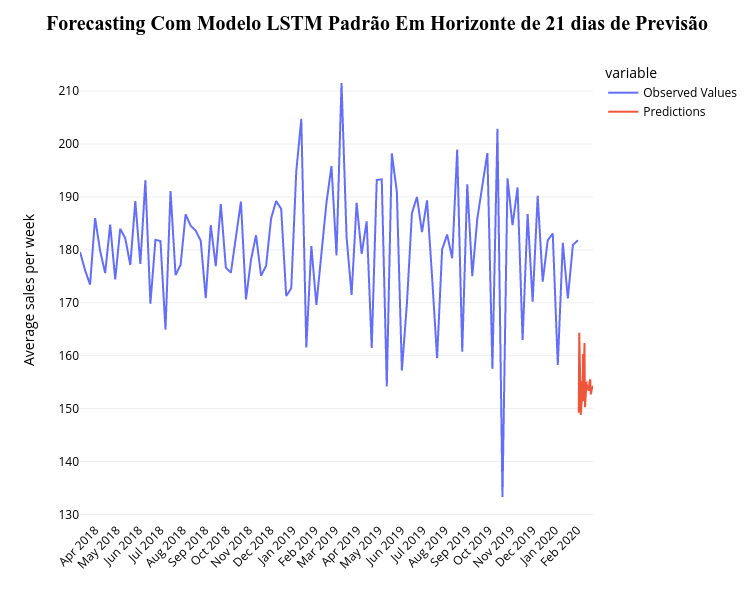

In [518]:
# Display graph
ts_series(
          df_forecasting,
          'Average_sales_per_week', 'Predictions',
          title="<b>Forecasting Com Modelo LSTM Padrão Em Horizonte de 21 dias de Previsão</b>",
          template="xgridoff"
)

### Salve the model

In [519]:
# Salva o modelo
def save_model(model):
    json_model = model.to_json()
    open('models/model_lstm.json', 'w').write(json_model)
    model.save_weights('models/model_lstm.h5', overwrite = True)

In [520]:
save_model(model_lstm)